1. 문제 정의
2. 데이터 이해 (EDA)

3. 첫 번째 베이스라인 모델 구축
   - Logistic Regression

4. 전처리 실험 과정
   4-1 중앙값 대체
   4-2 RobustScaler
   4-3 StandardScaler
   4-4 class_weight

5. 예상치 못한 문제 발견
   - Target Leakage ( 데이터 누락 )

6. 문제 수정 및 재실험
   6-1 Feature 재선정
   6-2 Decision Tree 실험

7. 최종 모델 선정 및 성능 비교

8. 프로젝트 회고
이번 프로젝트를 통해 단순히 모델 성능을 높이는 것보다,
데이터 전처리 과정의 작은 선택이 결과 해석에 큰 영향을 줄 수 있음을 경험하였다.
특히 Target Leakage를 직접 발견하고 수정하면서
모델링 이전 데이터 검증의 중요성을 체감하였다.

In [1]:
import pandas as pd

df = pd.read_csv("./data/diabetes.csv")
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [2]:
# outcome은 당뇨인지 아닌지 확인하는 컬럼이다
# 이 컬럼이 있으니 이 데이터는 분류로 진행을 해야겠다.
# 먼저 데이터 구조 및 컬럼 정보 확인
df.info()

# 모두 숫자형태

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.shape

(768, 9)

In [4]:
print(df.describe())
# 임신을 최대 17번??
# BMI가 최대 67까지 나올 수 있나?

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [5]:
print(df['Outcome'].value_counts())
print(df['Outcome'].value_counts(normalize = True))

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


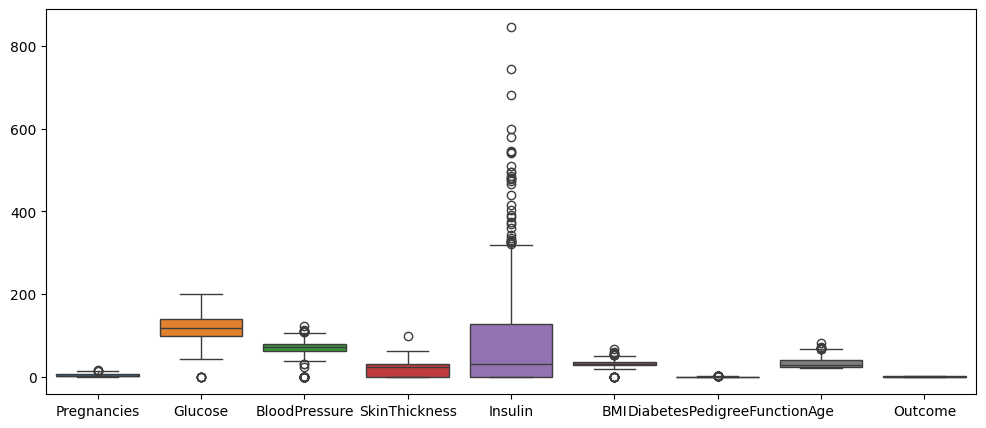

In [6]:
# 이상치 확인하기
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (12 ,5))
sns.boxplot(data = df)
plt.show()

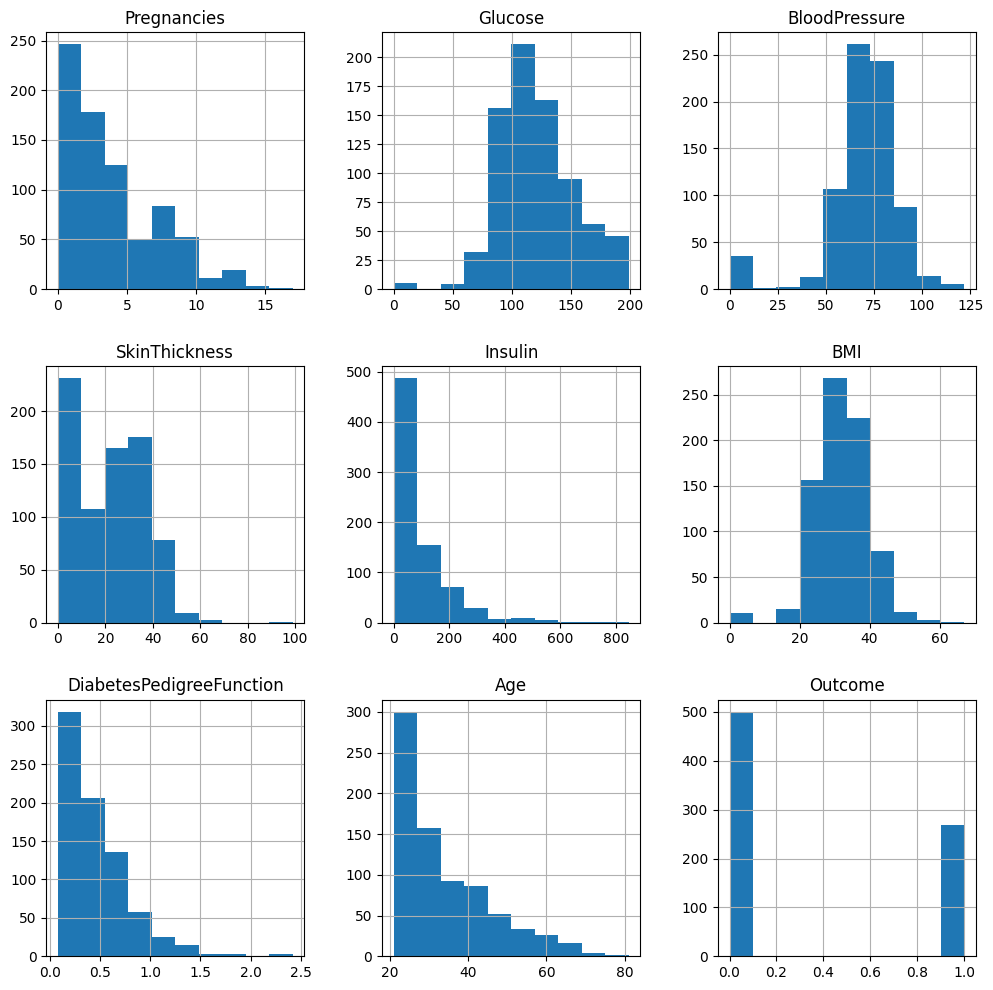

In [7]:
# 인슐린에서 많은 이상치가 있는 것으로 확인됨
# 변수 분포 확인
df.hist(figsize = (12, 12))
plt.show()

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [10]:
# 내 기준으로 이상치가 있다고 판단한 컬럼은 인슐린, 피부두께, BMI, 당뇨 유전 위험도
# 하지만 가장 큰 중요점은 인슐린에 값이 0으로만 있는 경우는 말이 안 되기 때문에 누락으로 생각
# outcome이 0과 1일때를 구분해서 그 값들의 중앙값으로 대체하는것이 맞다고 판단  먼저 그룹차이가 있는지 확인
df.groupby('Outcome')['Insulin'].median()

Outcome
0    39.0
1     0.0
Name: Insulin, dtype: float64

In [11]:
# 하지만 당뇨일 때 인슐린이 0이 나왔다는 것은 0이 너무 많아서 median자체로도 0이 나오게 된다
# 즉 숨은 결측치라고 판단
# 먼저 0을 NaN으로 대체한 후 중앙값 구하기
import numpy as np
df['Insulin'] = df['Insulin'].replace(0, np.nan)

df.groupby('Outcome')['Insulin'].median()

Outcome
0    102.5
1    169.5
Name: Insulin, dtype: float64

In [12]:
# NaN값에 중앙값 넣기
df['Insulin'] = df.groupby('Outcome')['Insulin'].transform(
    lambda x : x.fillna(x.median())
)
print(df['Insulin'].isnull().sum())
print(df.groupby('Outcome')['Insulin'].describe())

0
         count        mean        std   min    25%    50%    75%    max
Outcome                                                                
0        500.0  117.172000  75.685302  15.0   95.0  102.5  105.0  744.0
1        268.0  187.615672  94.114420  14.0  169.5  169.5  169.5  846.0


In [13]:
# 이제 0으로 되어 있는 부분은 고쳤고 남은 것은 말도 안 되게 큰 값들을 해결하는것
# 추가적으로 데이터를 좀 자세히 봤더니 피부 두께에서도 0이라는 말도 안되는 수치 발견 -> 인슐린하고 동일한 작업 해주기
print(df.groupby('Outcome')['SkinThickness'].describe())

         count       mean        std  min  25%   50%   75%   max
Outcome                                                         
0        500.0  19.664000  14.889947  0.0  0.0  21.0  31.0  60.0
1        268.0  22.164179  17.679711  0.0  0.0  27.0  36.0  99.0


In [14]:
df['SkinThickness'] = df['SkinThickness'].replace(0, np.nan)

df['SkinThickness'] = df.groupby('Outcome')['SkinThickness'].transform(
    lambda x: x.fillna(x.median())
)

print(df['SkinThickness'].isnull().sum())

0


In [15]:
print(df[['SkinThickness', 'Outcome']].corr())
# 전처리를 하니 상관관계를 봤을 때 0.075에서 0.29로 4배 상승
# 추가적으로 BMI, 혈압, 혈당 역시 0이 많지는 않지만 그래도 있으므로 이것도 전처리
# 하지만 인슐린과 다르게 outcome나누어서 계산하는 것보다 그냥 한번에 중앙값으로 처리하는 것이 더 낫다고 판단
# 과한 전처리는 피하기

               SkinThickness   Outcome
SkinThickness       1.000000  0.295138
Outcome             0.295138  1.000000


In [16]:
df['BMI'] = df['BMI'].replace(0, np.nan)
df['BMI'] = df['BMI'].fillna(df['BMI'].median())

print(df[['BMI', 'Outcome']].corr())

              BMI   Outcome
BMI      1.000000  0.312038
Outcome  0.312038  1.000000


In [17]:
# 혈당 역시 전처리
df['Glucose'] = df['Glucose'].replace(0, np.nan)
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].median())

print(df[['Glucose', 'Outcome']].corr())

          Glucose   Outcome
Glucose  1.000000  0.492782
Outcome  0.492782  1.000000


In [18]:
# 혈압 전처리
df['BloodPressure'] = df['BloodPressure'].replace(0, np.nan)
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].median())

print(df[['BloodPressure', 'Outcome']].corr())

               BloodPressure   Outcome
BloodPressure       1.000000  0.165723
Outcome             0.165723  1.000000


In [19]:
### baseline모델을 만들자 
### baseline을 만들고 위에서 분석한 결과로 이상치 등을 처리한 모델과 비교

### 결측치만 처리하자.. 결측치를 처리 할때, 제거, 평균, 중앙값 
### 베이스 라인 중 이중에 평균으로 하자.
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.

#2. 결측치처리
df2.fillna(df2.mean(), inplace=True)
# print(df.isnull().sum())

#3. 입력피처, 타켓분리
X=df2.drop("Outcome", axis=1)
y=df2['Outcome']
#print(y)

#4. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))

Accuracy 0.7792207792207793
Precison 0.6981132075471698
Recall 0.6727272727272727
F1-score 0.6851851851851852


In [20]:
### baseline모델을 만들자 
### baseline을 만들고 위에서 분석한 결과로 이상치 등을 처리한 모델과 비교

### 결측치만 처리하자.. 결측치를 처리 할때, 제거, 평균, 중앙값 
### 베이스 라인 중 이중에 중앙값으로 하자.
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.

#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())

#3. 입력피처, 타켓분리
X=df2.drop("Outcome", axis=1)
y=df2['Outcome']
#print(y)

#4. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))

Accuracy 0.7792207792207793
Precison 0.6981132075471698
Recall 0.6727272727272727
F1-score 0.6851851851851852


In [21]:
# IQR 공식을 사용할 경우
## 이상치 처리를 IQR공식
# 베이스 모델에서 > 결측치를 중앙값으로 한다면?
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.
print(df2.shape)
#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())

#2.1 이상치 처리  IQR 
outlier_cols=['Glucose', 'Insulin']
for col in outlier_cols:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)    
    IQR = Q3- Q1    
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    ## lower_bound 이하와 upper_bound이상은 제거    
    df2 = df2[
        (df2[col] >= lower_bound)&(df2[col] <= upper_bound)
    ]
print(df2.shape)

#3. 입력피처, 타켓분리
X=df2.drop("Outcome", axis=1)
y=df2['Outcome']
#print(y)

#4. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))

(768, 9)
(717, 9)
Accuracy 0.875
Precison 0.782608695652174
Recall 0.8181818181818182
F1-score 0.8


In [22]:
# 스케일링을 데이터셋을 분리한 후 진행


## 이상치 처리를 StandardScaler
## 이상치 처리를 IQR공식
# 베이스 모델에서 > 결측치를 중앙값으로 한다면?
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.
print(df2.shape)
#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())

#2. 입력피처, 타켓분리
X=df2.drop("Outcome", axis=1)
y=df2['Outcome']
#print(y)

#3. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#4.1 StandardScaler
#모든 컬럼을 다 해보자
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#타켓을 제외한 컬럼을 모두 변경하려고 한다. 컬럼선택
feature_cols = df2.drop("Outcome", axis=1).columns
df2[feature_cols]=scaler.fit_transform(df2[feature_cols])
print("스케일링 후", df2.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))


(768, 9)
스케일링 후 (768, 9)
Accuracy 0.7792207792207793
Precison 0.6981132075471698
Recall 0.6727272727272727
F1-score 0.6851851851851852


In [23]:
# 한번 스케일링을 해보자
## 이상치 처리를 StandardScaler
## 이상치 처리를 IQR공식
# 베이스 모델에서 > 결측치를 중앙값으로 한다면?
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.
print(df2.shape)
#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())

#2.1 StandardScaler
#모든 컬럼을 다 해보자
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#타켓을 제외한 컬럼을 모두 변경하려고 한다. 컬럼선택
feature_cols = df2.drop("Outcome", axis=1).columns
df2[feature_cols]=scaler.fit_transform(df2[feature_cols])
print("스케일링 후", df2.shape)

#3. 입력피처, 타켓분리
X=df2.drop("Outcome", axis=1)
y=df2['Outcome']
#print(y)

#4. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000) #1000번 반복해서 공부해

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))


(768, 9)
스케일링 후 (768, 9)
Accuracy 0.7792207792207793
Precison 0.6981132075471698
Recall 0.6727272727272727
F1-score 0.6851851851851852


In [24]:
# 평균으로 해보았을 때 역시 엄청 큰 차이가 있지 않고 거의 비슷한것으로 보아서 class_weight = 'balanced'를 주어서 recall 확률 올려보기
#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.
print(df2.shape)
#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())

#2. 입력피처, 타켓분리
X=df2.drop("Outcome", axis=1)
y=df2['Outcome']
#print(y)

#3. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#4.1 StandardScaler
#모든 컬럼을 다 해보자
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#타켓을 제외한 컬럼을 모두 변경하려고 한다. 컬럼선택
feature_cols = df2.drop("Outcome", axis=1).columns
df2[feature_cols]=scaler.fit_transform(df2[feature_cols])
print("스케일링 후", df2.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000,#1000번 반복해서 공부해
                           class_weight = 'balanced') # 적은 클래스를 더 중요하게 공부

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))


(768, 9)
스케일링 후 (768, 9)
Accuracy 0.7597402597402597
Precison 0.6285714285714286
Recall 0.8
F1-score 0.704


In [25]:
# 더 적은 클래스 위주로 공부를 시키니 Recall값은 올랐으나 정확도가 약 76%로 1~3%대로 떨어지는 것을 확인할 수 있음
# 불균형 데이터에서 정확도보다는 실제 환자를 놓치지 않는 탐지 성능(recall)을 우선적으로 고려한 결과
# 다음은 standardScaler가 아닌 RobustScaler로 해보자

#0. 라이브러리
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#1. 데이터 준비
df2=df.copy()  ## df원본인데 복사해서 사용하려고 함.
print(df2.shape)
#2. 결측치처리
df2.fillna(df2.median(), inplace=True)
# print(df.isnull().sum())

#2. 입력피처, 타켓분리
X=df2.drop("Outcome", axis=1)
y=df2['Outcome']
#print(y)

#3. 데이터 셋 분리
X_train, X_test, y_train, y_test =train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# print(X_train.shape)

#4.1 RobustScaler
#모든 컬럼을 다 해보자
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

#타켓을 제외한 컬럼을 모두 변경하려고 한다.
feature_cols = df2.drop("Outcome", axis=1).columns
df2[feature_cols]=scaler.fit_transform(df2[feature_cols])
print("스케일링 후", df2.shape)

#5. 모델생성 :  분류모델을 개발.. 이중에 로지스틱회귀를 분류 모델
model = LogisticRegression(max_iter=1000,#1000번 반복해서 공부해
                           class_weight = 'balanced') # 적은 클래스를 더 중요하게 공부

#6. 모델학습
model.fit(X_train,y_train)

#7. 평가 (학습된 모델로 예측값을 가져오고, 실제 값하고 비교해서 )
pred = model.predict(X_test)
# 분류 평가. Accuracy, Precision, Recall, F1-score
print('Accuracy', accuracy_score(y_test, pred))
print('Precison', precision_score(y_test, pred))
print('Recall', recall_score(y_test, pred))
print('F1-score', f1_score(y_test, pred))


(768, 9)
스케일링 후 (768, 9)
Accuracy 0.7597402597402597
Precison 0.6285714285714286
Recall 0.8
F1-score 0.704


In [26]:
# 데이터 셋 나누기
from sklearn.model_selection import train_test_split

X = df[['Glucose', 'Insulin', 'BMI']]
print(X.shape)
y = df['Outcome']
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

(768, 3)
(768,)


In [27]:
# 어제 같은 주제로 했던 것을 이번엔 비선형 모델인 결정트리 모델로 선택
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth = 3, # 깊이가 너무 많으면 잘못 학습되는 과적합 발생하기에 이것을 방지
    min_samples_leaf = 5, # 5개의 샘플로 분류, 회귀 결과값
    #불순도 계산 방식
    criterion = "gini",
    class_weight = "balanced"
)

In [28]:
# 학습
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

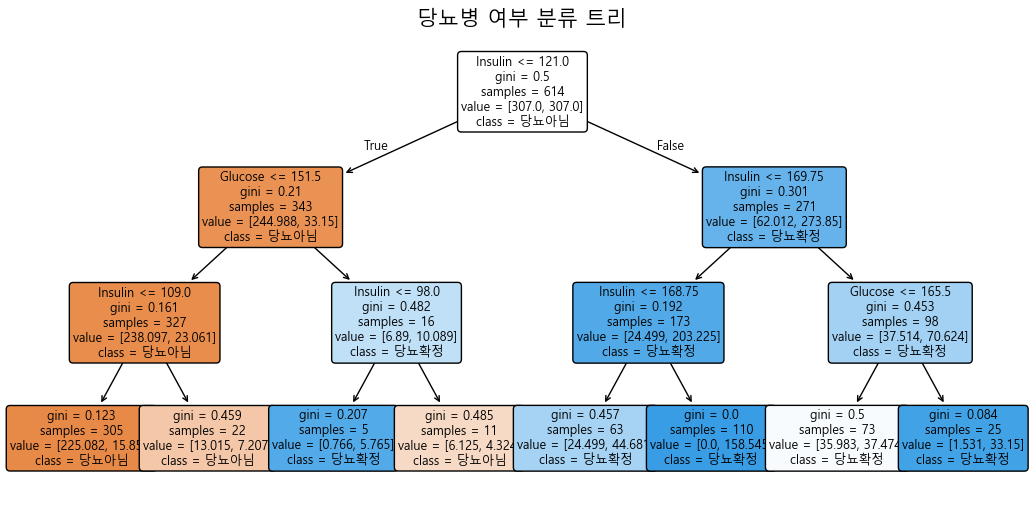

In [29]:
# 결정 트리 그리기
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 분류 모델 시각화
plt.figure(figsize = (13, 6))
plot_tree(model,
          feature_names = X.columns,
          class_names = ['당뇨아님', '당뇨확정'],
          filled = True,
          rounded = True,
          fontsize = 9)
plt.title("당뇨병 여부 분류 트리", fontsize = 15)
plt.show()


In [30]:
# 결정트리를 보니 조금 이상한 부분 발견
# 샘플 수가 적은건 아닌지 의심해보고 한 번 20개로 늘려서 진행 해보자

model = DecisionTreeClassifier(
    max_depth = 3, # 깊이가 너무 많으면 잘못 학습되는 과적합 발생하기에 이것을 방지
    min_samples_leaf = 20, # 5개의 샘플로 분류, 회귀 결과값
    min_samples_split = 40, # 40명 이상일 때만 쪼개는 것
    #불순도 계산 방식
    criterion = "gini",
    class_weight = "balanced"
)

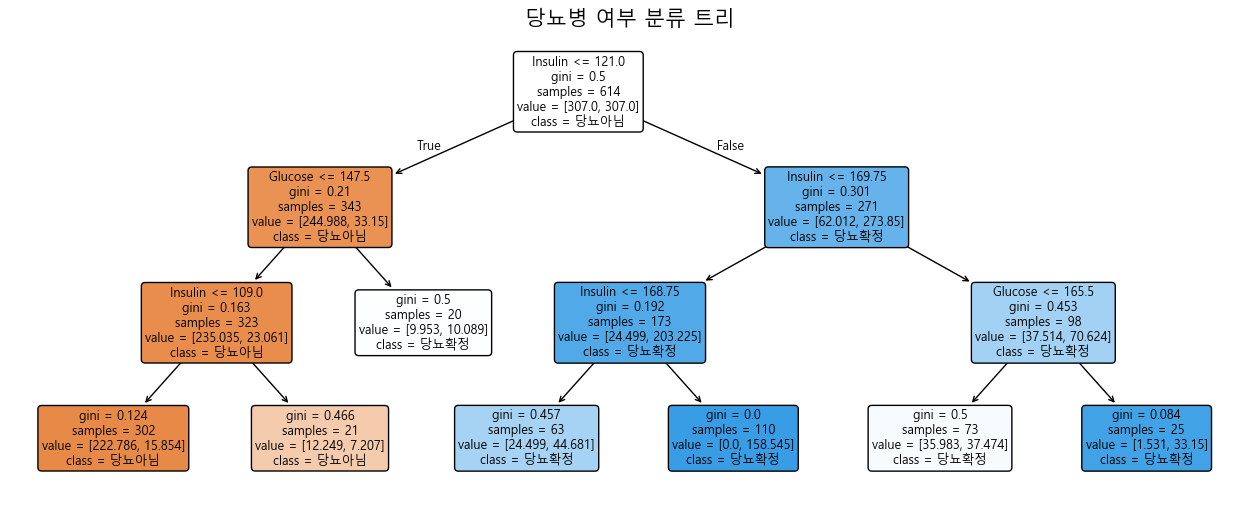

In [31]:
# 학습
model.fit(X_train, y_train)

# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 분류 모델 시각화
plt.figure(figsize = (16, 6))
plot_tree(model,
          feature_names = X.columns,
          class_names = ['당뇨아님', '당뇨확정'],
          filled = True,
          rounded = True,
          fontsize = 9)
plt.title("당뇨병 여부 분류 트리", fontsize = 15)
plt.show()

In [32]:
# 인슐린을 아무래도 Outcoome 기준으로 채우다보니 모델이 인슐린을 강하게 보면서 인슐린의 비중이 높음
for name, score in zip(X.columns, model.feature_importances_):
    print(name, score)
    
# BMI는 0%이고 인슐린이 91퍼인걸 보면 정답 정보가 feature에 반영돼서 과적합 현상이 발생한거 같음
# 그렇다면 인슐린을 한번 outcome기준으로 두는 것이 아니라 전체 중앙값을 두어서 전처리를 해보겠음

df2 = df.copy()

df2['Insulin'] = df2['Insulin'].replace(0, np.nan)

df2['Insulin'] = df2['Insulin'].fillna(
    df2['Insulin'].median()
)

Glucose 0.0841450563948474
Insulin 0.9158549436051526
BMI 0.0


In [33]:
X = df2[['Glucose', 'Insulin', 'BMI']]
print(X.shape)
y = df2['Outcome']
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

(768, 3)
(768,)


In [34]:
model = DecisionTreeClassifier(
    max_depth = 3, # 깊이가 너무 많으면 잘못 학습되는 과적합 발생하기에 이것을 방지
    min_samples_leaf = 20, # 5개의 샘플로 분류, 회귀 결과값
    min_samples_split = 40, # 40명 이상일 때만 쪼개는 것
    #불순도 계산 방식
    criterion = "gini",
    class_weight = "balanced"
)

In [35]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",40
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

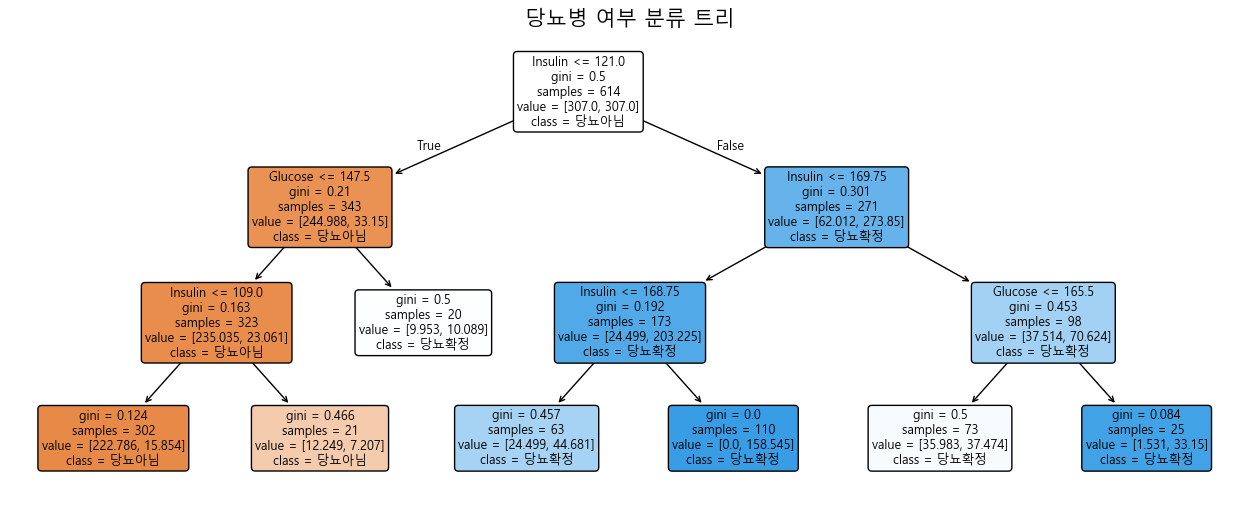

In [36]:
# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 분류 모델 시각화
plt.figure(figsize = (16, 6))
plot_tree(model,
          feature_names = X.columns,
          class_names = ['당뇨아님', '당뇨확정'],
          filled = True,
          rounded = True,
          fontsize = 9)
plt.title("당뇨병 여부 분류 트리", fontsize = 15)
plt.show()

In [37]:
for name, score in zip(X.columns, model.feature_importances_):
    print(name, score)

# 지금 생각해보니 원본 데이터 자체를 바꾸었기 때문에 이 df2로 복사해도 똑같은 현상 발견 clean하기

df_clean = pd.read_csv("./data/diabetes.csv")

Glucose 0.08414505639484708
Insulin 0.915854943605153
BMI 0.0


In [38]:
df_clean['Insulin'] = df_clean['Insulin'].replace(0, np.nan)

df_clean['Insulin'] = df_clean['Insulin'].fillna(df_clean['Insulin'].median())

In [39]:
X = df_clean[['Insulin', 'BMI', 'Glucose']]
y = df_clean['Outcome']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [41]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=20,
    min_samples_split=40,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",40
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

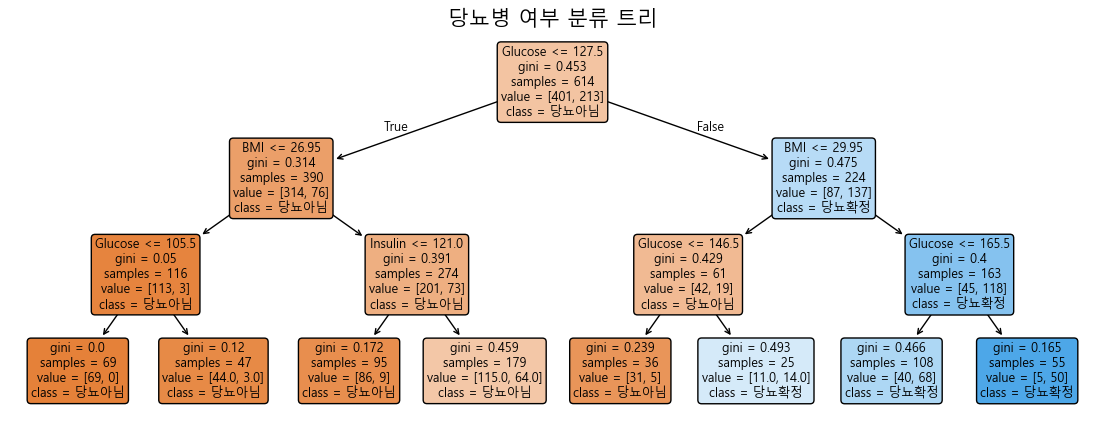

In [45]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 분류 모델 시각화
plt.figure(figsize = (14, 5))
plot_tree(model,
          feature_names = X.columns,
          class_names = ['당뇨아님', '당뇨확정'],
          filled = True,
          rounded = True,
          fontsize = 9)
plt.title("당뇨병 여부 분류 트리", fontsize = 15)
plt.show()

In [43]:
for name, score in zip(X.columns, model.feature_importances_):
    print(name, score)

Insulin 0.09151223204176061
BMI 0.2619016505208833
Glucose 0.6465861174373562


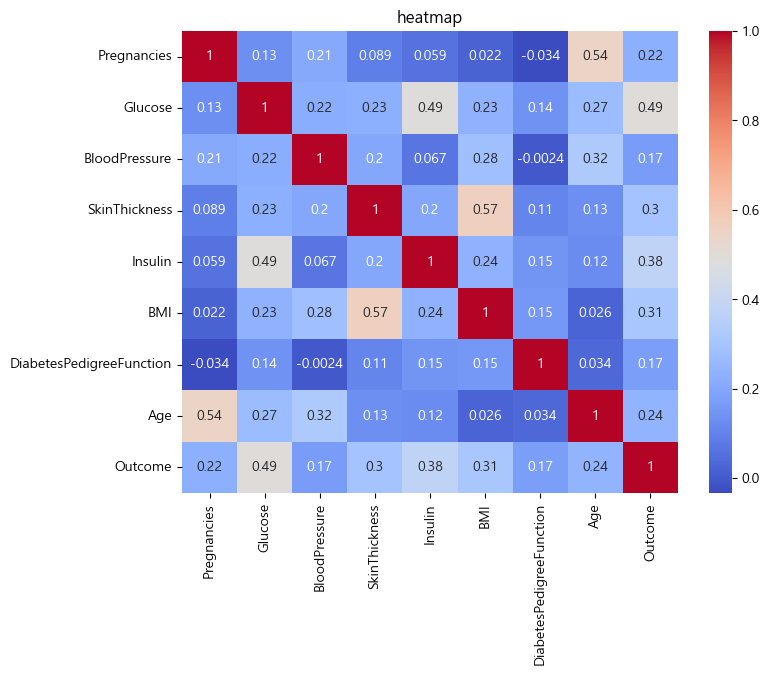

In [44]:
# 새로 만들어 진행해보니 혈당이 64%, BMI가 26%, 인슐린이 9%로 다른 형상을 보여주었다.
# 이전 heatmap을 보면 혈당이 가장 outcome과 상관관계가 있다는 것과 일치하는 것을 볼 수 있음
# 인슐린이 BMI보다 높아도 Glucose랑 0.49로 엄청난 연관성을 가지고 있기 때문에 outcome하고 했을 때 BMI보다 떨어지는걸 알 숭 ㅣㅆ음
# 이를 중복 정보라고 함

# 변수 간의 상관관계 확인
corr = df2.corr()

plt.figure(figsize = (8, 6))
sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm"
)
plt.title("heatmap")
plt.show()